In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

In [3]:
data = pd.read_csv('creditcard.csv')
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


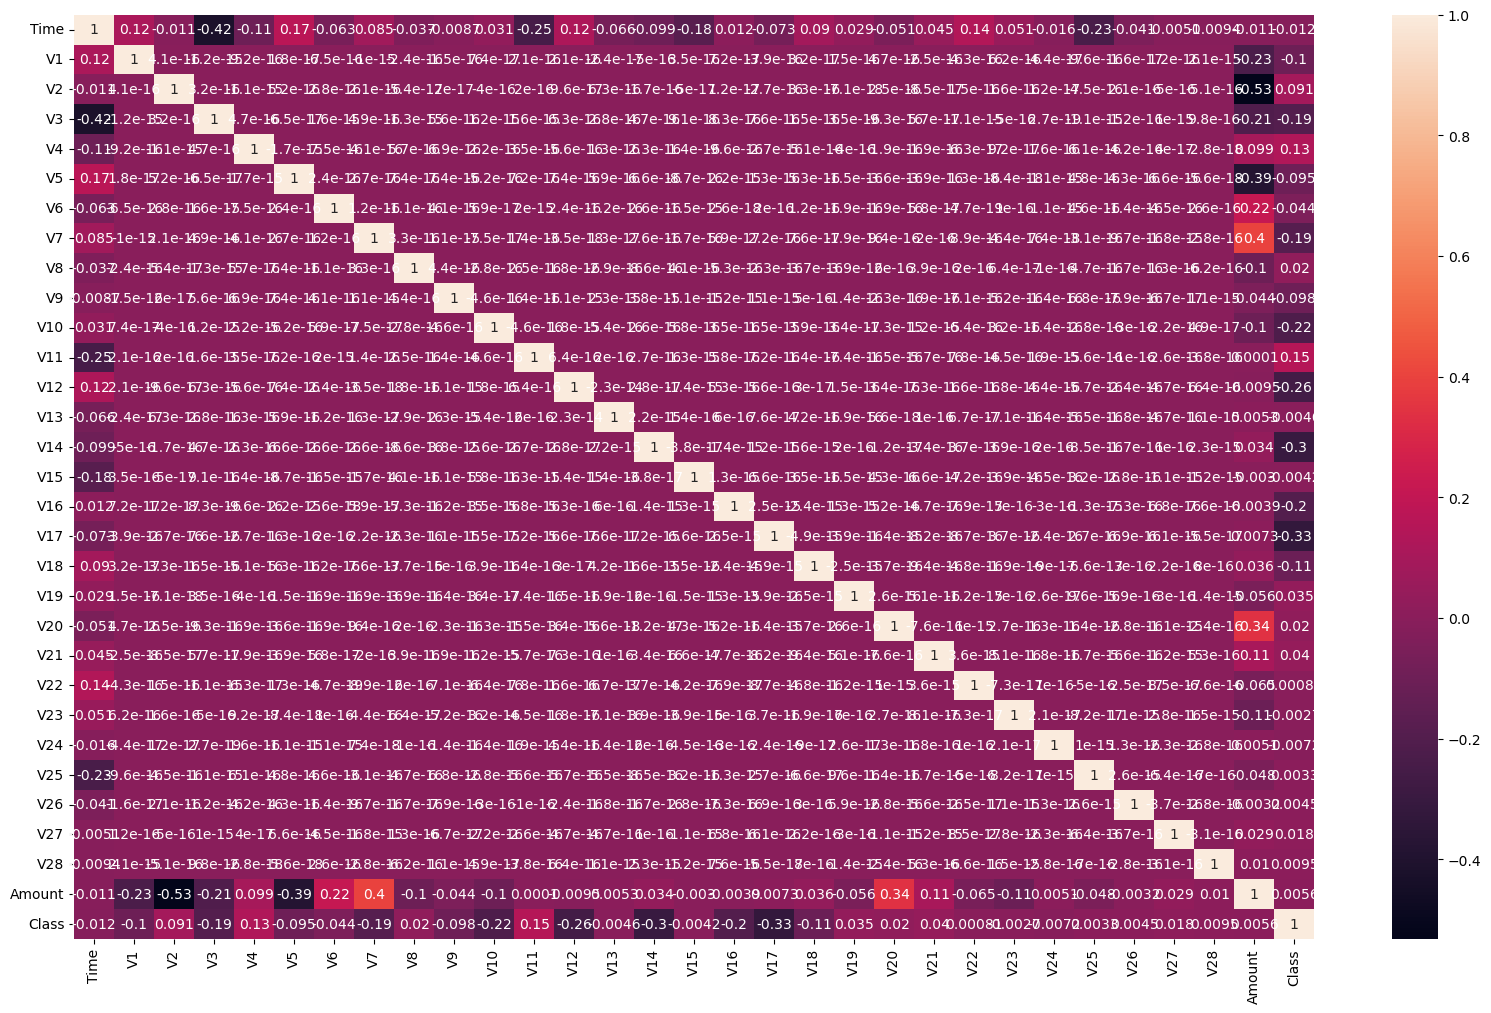

In [4]:
plt.figure(figsize=(20, 12))
sns.heatmap(data.corr(), annot=True)
plt.show()

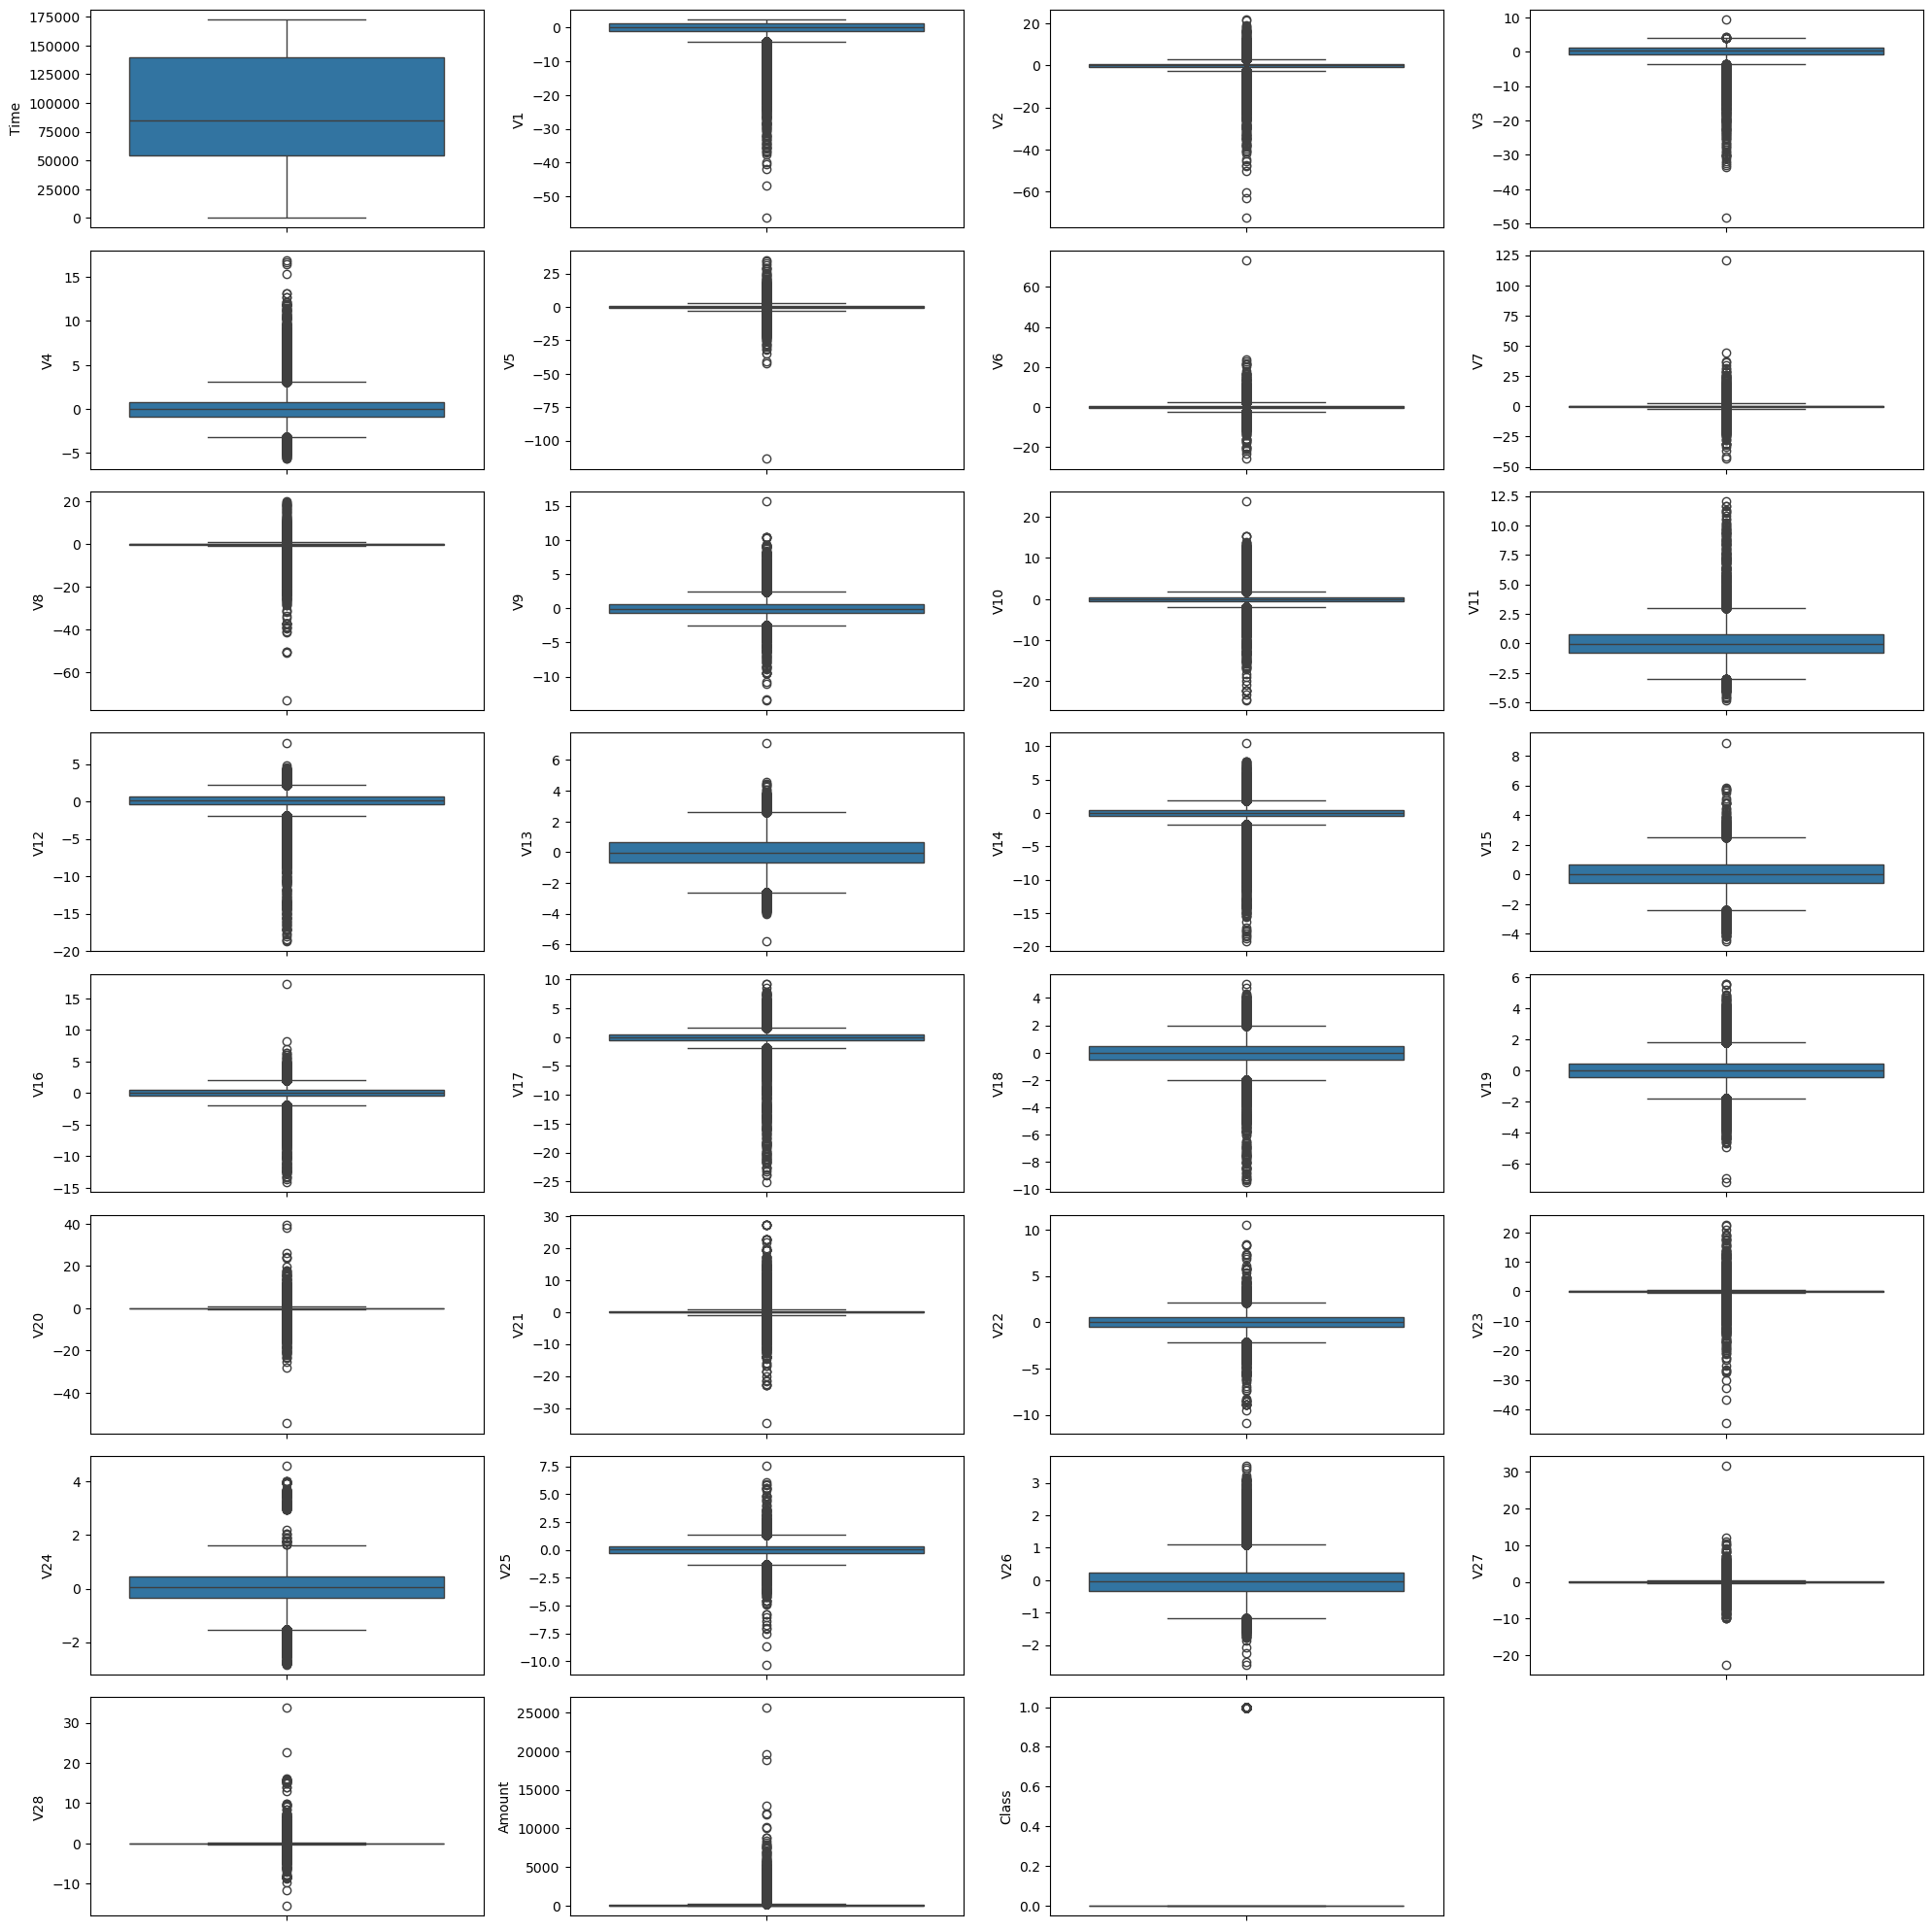

In [8]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(data.columns):
    plt.subplot(8, 4, i+1)
    sns.boxplot(data[col])
plt.tight_layout()

In [ ]:
scaler = RobustScaler()
data['scaled_amount'] = scaler.fit_transform(data['Amount'].values.reshape(-1, 1))
data['scaled_time'] = scaler.fit_transform(data['Time'].values.reshape(-1, 1))
data.drop(['Time', 'Amount'], axis=1, inplace=True)

normal_data = data[data['Class'] == 0]
fraud_data = data[data['Class'] == 1]

X_normal = normal_data.drop(['Class'], axis=1).values
X_fraud = fraud_data.drop(['Class'], axis=1).values

X_train, X_test_normal = train_test_split(X_normal, test_size=0.2, random_state=42)

X_train_tensor = torch.FloatTensor(X_train)
X_test_normal_tensor = torch.FloatTensor(X_test_normal)
X_fraud_tensor = torch.FloatTensor(X_fraud)

train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=256, shuffle=True)

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        
        # Encoder: Compresses data
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 20),
            nn.Tanh(),
            nn.Linear(20, 14),
            nn.Tanh(),
            nn.Linear(14, 8), # Bottleneck (Latent Space)
            nn.Tanh(),
        )
        
        # Decoder: Reconstructs data
        self.decoder = nn.Sequential(
            nn.Linear(8, 14),
            nn.Tanh(),
            nn.Linear(14, 20),
            nn.Tanh(),
            nn.Linear(20, input_dim),
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Initialize Model
input_dim = X_train.shape[1] 
model = Autoencoder(input_dim)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=30, out_features=20, bias=True)
    (1): Tanh()
    (2): Linear(in_features=20, out_features=14, bias=True)
    (3): Tanh()
    (4): Linear(in_features=14, out_features=8, bias=True)
    (5): Tanh()
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=14, bias=True)
    (1): Tanh()
    (2): Linear(in_features=14, out_features=20, bias=True)
    (3): Tanh()
    (4): Linear(in_features=20, out_features=30, bias=True)
  )
)

In [ ]:
num_epochs = 50
learning_rate = 1e-3
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"Training on {device}...")

for epoch in range(num_epochs):
    loss = 0
    for batch_features in train_loader:
        batch_features = batch_features[0].to(device)
        optimizer.zero_grad()
        outputs = model(batch_features)
        train_loss = criterion(outputs, batch_features)
        train_loss.backward()
        optimizer.step()
        
        loss += train_loss.item()
    
    loss = loss / len(train_loader)
    
    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss:.6f}')

print("Training Complete.")

Training on cuda...
Epoch [5/50], Loss: 0.434178
Epoch [10/50], Loss: 0.342398
Epoch [15/50], Loss: 0.311427
Epoch [20/50], Loss: 0.294488
Epoch [25/50], Loss: 0.280927
Epoch [30/50], Loss: 0.269793
Epoch [35/50], Loss: 0.259449
Epoch [40/50], Loss: 0.255574
Epoch [45/50], Loss: 0.249853
Epoch [50/50], Loss: 0.245662
Training Complete.


In [ ]:
model.eval()

with torch.no_grad():
    reconstructions_normal = model(X_test_normal_tensor.to(device))
    loss_normal = torch.mean((X_test_normal_tensor.to(device) - reconstructions_normal) ** 2, dim=1)

with torch.no_grad():
    reconstructions_fraud = model(X_fraud_tensor.to(device))
    loss_fraud = torch.mean((X_fraud_tensor.to(device) - reconstructions_fraud) ** 2, dim=1)

print(f"Avg Reconstruction Error (Normal): {torch.mean(loss_normal).item()}")
print(f"Avg Reconstruction Error (Fraud): {torch.mean(loss_fraud).item()}")

threshold = np.percentile(loss_normal.cpu().numpy(), 95)
print(f"Suggested Threshold: {threshold}")

Avg Reconstruction Error (Normal): 0.2880455255508423
Avg Reconstruction Error (Fraud): 19.448108673095703
Suggested Threshold: 0.5667684078216553


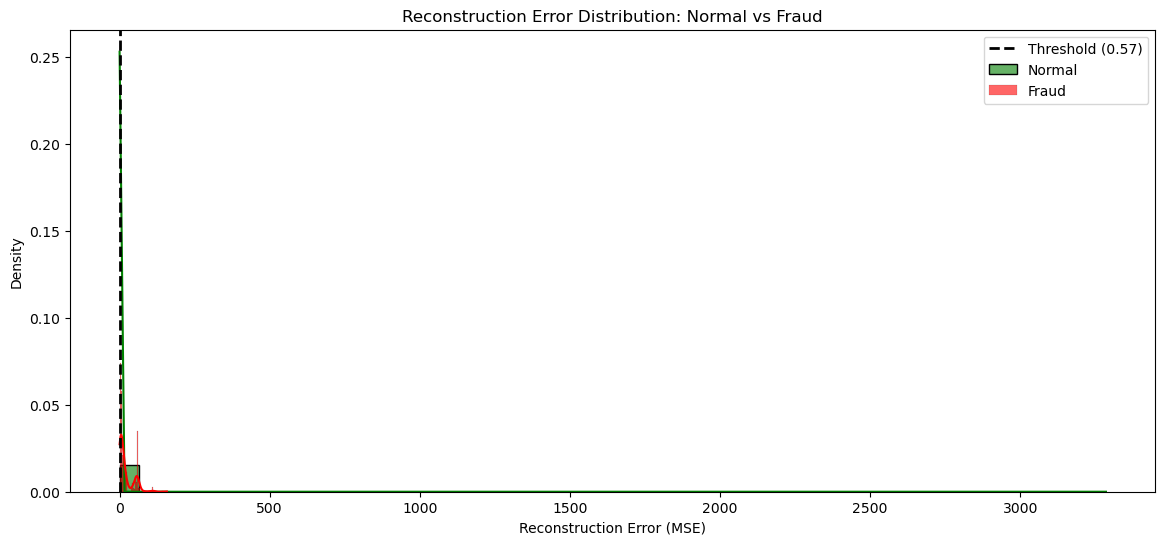

In [ ]:
loss_normal_np = loss_normal.cpu().numpy()
loss_fraud_np = loss_fraud.cpu().numpy()

plt.figure(figsize=(14, 6))
sns.histplot(loss_normal_np, bins=50, kde=True, color='green', label='Normal', stat='density', alpha=0.6)
sns.histplot(loss_fraud_np, bins=50, kde=True, color='red', label='Fraud', stat='density', alpha=0.6)
plt.axvline(threshold, color='black', linestyle='dashed', linewidth=2, label=f'Threshold ({threshold:.2f})')

plt.title('Reconstruction Error Distribution: Normal vs Fraud')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Density')
plt.legend()
plt.show()

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97     56863
       Fraud       0.13      0.86      0.22       492

    accuracy                           0.95     57355
   macro avg       0.56      0.90      0.60     57355
weighted avg       0.99      0.95      0.97     57355



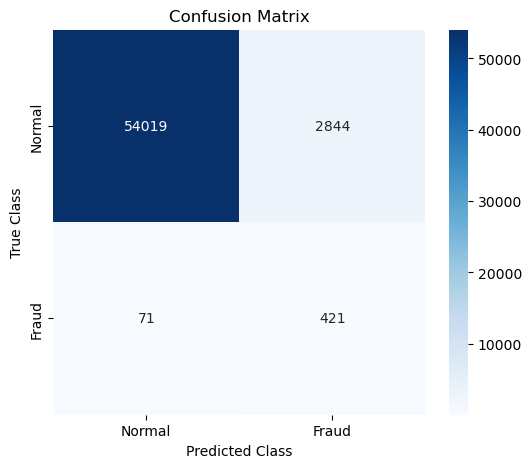

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# If error > threshold, classify as Fraud (1), else Normal (0)
pred_outliers = (loss_normal_np > threshold).astype(int)
pred_fraud = (loss_fraud_np > threshold).astype(int)

# Prepare True Labels
y_true_normal = np.zeros(len(loss_normal_np))
y_true_fraud = np.ones(len(loss_fraud_np))

# Concatenate all data for global evaluation
y_pred = np.concatenate([pred_outliers, pred_fraud])
y_true = np.concatenate([y_true_normal, y_true_fraud])

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Fraud']))
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.title('Confusion Matrix')
plt.show()

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score

def tune_threshold(loss_normal, loss_fraud, num_steps=100):
    # 1. Define the range of thresholds to test
    # We scan from the median normal error up to the max fraud error
    min_thresh = np.min(loss_normal)
    max_thresh = np.max(loss_fraud)
    thresholds = np.linspace(min_thresh, max_thresh, num_steps)
    
    results = []
    
    # 2. Loop through every threshold
    for thresh in thresholds:
        # Create predictions based on current threshold
        # 0 = Normal, 1 = Fraud
        pred_normal = (loss_normal > thresh).astype(int)
        pred_fraud = (loss_fraud > thresh).astype(int)
        
        # Combine predictions and true labels
        y_pred = np.concatenate([pred_normal, pred_fraud])
        y_true = np.concatenate([np.zeros(len(loss_normal)), np.ones(len(loss_fraud))])
        
        # Calculate Metrics
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        results.append({
            'Threshold': thresh,
            'Precision': precision,
            'Recall': recall,
            'F1_Score': f1,
            'False_Positives': np.sum(pred_normal) # How many normal users got annoyed
        })
        
    # 3. Create a clean DataFrame
    results_df = pd.DataFrame(results)
    return results_df

# --- RUN THE TUNER ---
# Convert tensors to numpy if you haven't already
loss_normal_np = loss_normal.cpu().numpy()
loss_fraud_np = loss_fraud.cpu().numpy()

# Get the results table
tuning_table = tune_threshold(loss_normal_np, loss_fraud_np)

# --- DISPLAY THE BEST OPTIONS ---

# Option A: Best Mathematical Balance (Max F1 Score)
best_f1 = tuning_table.loc[tuning_table['F1_Score'].idxmax()]

# Option B: "Business Safe" (High Precision - minimizes angry customers)
# We filter for Precision > 0.80 and then pick the best Recall left
high_precision_candidates = tuning_table[tuning_table['Precision'] > 0.80]
if not high_precision_candidates.empty:
    best_biz = high_precision_candidates.loc[high_precision_candidates['Recall'].idxmax()]
else:
    best_biz = tuning_table.loc[tuning_table['Precision'].idxmax()]

print("--- OPTION A: Best Balance (Max F1) ---")
print(best_f1)
print("\n--- OPTION B: Business Safe (Min 80% Precision) ---")
print(best_biz)

# Show a slice of the table to see the trade-off
print("\n--- Threshold Trade-off Table (Top 10 rows) ---")
print(tuning_table.head(10))

--- OPTION A: Best Balance (Max F1) ---
Threshold            3.192932
Precision            0.682883
Recall               0.770325
F1_Score             0.723973
False_Positives    176.000000
Name: 2, dtype: float64

--- OPTION B: Business Safe (Min 80% Precision) ---
Threshold           7.971813
Precision           0.806667
Recall              0.491870
F1_Score            0.611111
False_Positives    58.000000
Name: 5, dtype: float64

--- Threshold Trade-off Table (Top 10 rows) ---
   Threshold  Precision    Recall  F1_Score  False_Positives
0   0.007011   0.008578  1.000000  0.017011            56862
1   1.599972   0.490842  0.817073  0.613272              417
2   3.192932   0.682883  0.770325  0.723973              176
3   4.785892   0.750605  0.630081  0.685083              103
4   6.378852   0.790055  0.581301  0.669789               76
5   7.971813   0.806667  0.491870  0.611111               58
6   9.564773   0.833333  0.447154  0.582011               44
7  11.157733   0.847162  0.

In [27]:
def predict_and_explain(model, input_tensor, threshold, feature_names):
    model.eval()

    with torch.no_grad():
        reconstruction = model(input_tensor)
        
    loss_per_feature = (input_tensor - reconstruction) ** 2
    total_loss = torch.mean(loss_per_feature).item()
    status = "Fraud" if total_loss > threshold else "Normal"
    feature_errors = loss_per_feature.cpu().numpy()[0]
    
    sorted_indices = np.argsort(feature_errors)[::-1]
    
    print(f"--- Transaction Assessment ---")
    print(f"Status: {status}")
    print(f"Total Anomaly Score: {total_loss:.4f} (Threshold: {threshold:.4f})")
    
    if status == "Fraud":
        print("\nTop 3 Reasons (Highest Reconstruction Errors):")
        for i in range(3):
            idx = sorted_indices[i]
            error_val = feature_errors[idx]
            feat_name = feature_names[idx]
            
            actual_val = input_tensor[0][idx].item()
            predicted_val = reconstruction[0][idx].item()
            
            print(f"  {i+1}. {feat_name}: Error {error_val:.4f} (Actual: {actual_val:.2f} vs Model Expectation: {predicted_val:.2f})")
    
    return total_loss, sorted_indices

# === TESTING ===
feat_names = [f'V{i}' for i in range(1, 29)] + ['Scaled_Amount', 'Scaled_Time']

sample_fraud_transaction = X_fraud_tensor[100].unsqueeze(0).to(device)

predict_and_explain(model, sample_fraud_transaction, threshold=7.97, feature_names=feat_names)

--- Transaction Assessment ---
Status: Fraud
Total Anomaly Score: 20.8894 (Threshold: 7.9700)

Top 3 Reasons (Highest Reconstruction Errors):
  1. V17: Error 204.2278 (Actual: -12.62 vs Model Expectation: 1.67)
  2. V14: Error 108.8936 (Actual: -8.60 vs Model Expectation: 1.83)
  3. V12: Error 64.0050 (Actual: -7.78 vs Model Expectation: 0.22)


(20.889392852783203,
 array([16, 13, 11, 15,  9, 17, 10,  6,  8,  2,  3, 12,  1,  7, 18,  5,  0,
        28,  4, 14, 19, 29, 21, 20, 26, 27, 23, 24, 25, 22]))